<a href="https://colab.research.google.com/github/Namitha0203/Weather-Temperature-Prediction-using-RNN/blob/main/Weather_Temperature_Prediction_using_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Load the dataset and explore:**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muthuj7/weather-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.23M/2.23M [00:00<00:00, 68.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1


In [3]:
import os

In [5]:
os.listdir(path)

['weatherHistory.csv']

In [6]:
dataset = pd.read_csv(os.path.join(path, 'weatherHistory.csv'))
dataset.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [8]:
dataset['Formatted Date'] = pd.to_datetime(dataset['Formatted Date'], utc=True)
dataset = dataset.set_index('Formatted Date')



### **Plot temperature trend over time**

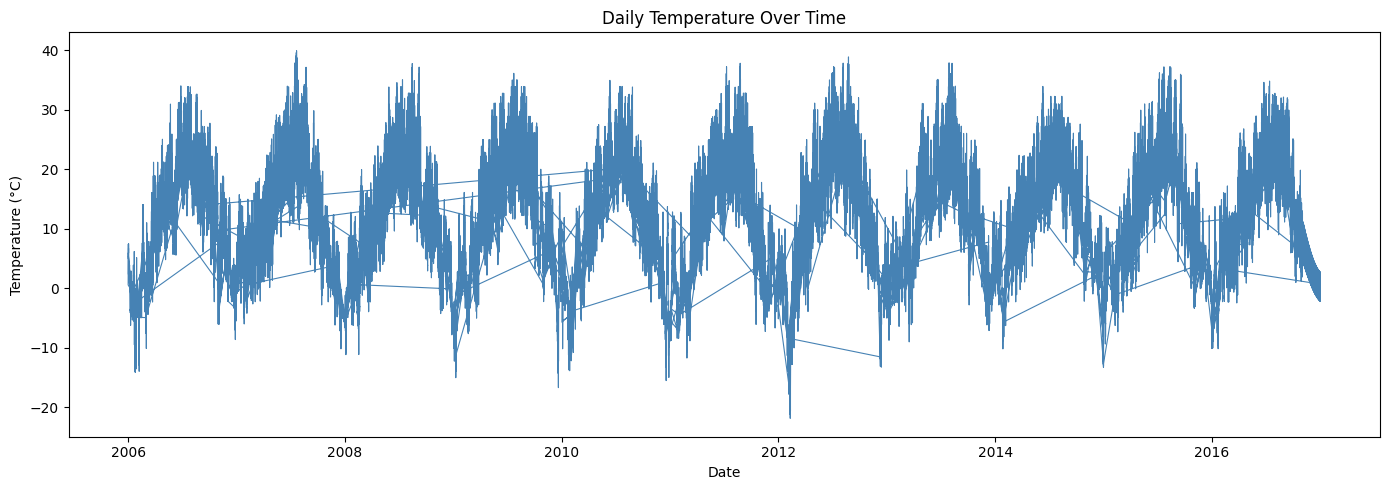

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(dataset.index, dataset['Temperature (C)'], color='steelblue', linewidth=0.8)
plt.title('Daily Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

### **Check for missing values.**

In [10]:
missing_values = dataset.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


## **2. Preprocess the data:**

### **Handle Missing Values**
As identified, 'Precip Type' has 517 missing values. Since this is a small fraction of the total dataset, we will drop these rows to simplify preprocessing.

In [11]:
dataset_cleaned = dataset.dropna(subset=['Precip Type']).copy()
print(f"Shape of dataset after dropping missing values: {dataset_cleaned.shape}")

# Verify no more missing values in 'Precip Type'
print("Missing values after dropping:")
print(dataset_cleaned.isnull().sum())

Shape of dataset after dropping missing values: (95936, 11)
Missing values after dropping:
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


### **Feature Selection and Target Variable Definition**
We will select 'Temperature (C)', 'Humidity', and 'Wind Speed (km/h)' as our features, and 'Temperature (C)' as the target variable for next day's prediction.

In [12]:
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']
target = 'Temperature (C)'

data = dataset_cleaned[features]

print("Features selected:")
print(data.head())

Features selected:
                           Temperature (C)  Humidity  Wind Speed (km/h)
Formatted Date                                                         
2006-03-31 22:00:00+00:00         9.472222      0.89            14.1197
2006-03-31 23:00:00+00:00         9.355556      0.86            14.2646
2006-04-01 00:00:00+00:00         9.377778      0.89             3.9284
2006-04-01 01:00:00+00:00         8.288889      0.83            14.1036
2006-04-01 02:00:00+00:00         8.755556      0.83            11.0446


### **Normalize Values using MinMaxScaler**
Normalizing the features helps RNNs converge faster and perform better.

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print("Scaled data (first 5 rows of first 3 columns):")
print(data_scaled[:5, :])

Scaled data (first 5 rows of first 3 columns):
[[0.50697507 0.89       0.2211296 ]
 [0.50508505 0.86       0.22339889]
 [0.50544505 0.89       0.06152295]
 [0.48780488 0.83       0.22087746]
 [0.49536495 0.83       0.17297025]]


### **Create Input Sequences and Target**
We need to create sequences of past data as input (`X`) and the corresponding next day's temperature as the target (`y`). We'll use a sequence length of 7 days.

In [14]:
def create_sequences(data, target_idx, sequence_length):
    xs, ys = [], []
    for i in range(len(data) - sequence_length):
        x = data[i:(i + sequence_length)]
        y = data[i + sequence_length, target_idx] # Next day's temperature
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

sequence_length = 7 # Use past 7 days' data
target_feature_index = features.index(target) # Index of 'Temperature (C)' in our features list

X, y = create_sequences(data_scaled, target_feature_index, sequence_length)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target temperatures): {y.shape}")
print("\nFirst sample of X:")
print(X[0])
print("\nFirst sample of y:")
print(y[0])

Shape of X (input sequences): (95929, 7, 3)
Shape of y (target temperatures): (95929,)

First sample of X:
[[0.50697507 0.89       0.2211296 ]
 [0.50508505 0.86       0.22339889]
 [0.50544505 0.89       0.06152295]
 [0.48780488 0.83       0.22087746]
 [0.49536495 0.83       0.17297025]
 [0.50292503 0.85       0.21860817]
 [0.47880479 0.95       0.19364599]]

First sample of y:
0.49563495634956356


### **Split Dataset into Train, Validation, and Test Sets**
We will split the data into 70% training, 15% validation, and 15% testing sets.

In [15]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, y_train = X[0:train_size], y[0:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:len(X)], y[train_size + val_size:len(X)]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (67150, 7, 3), y_train shape: (67150,)
X_val shape: (14389, 7, 3), y_val shape: (14389,)
X_test shape: (14390, 7, 3), y_test shape: (14390,)


# **Part B: RNN Model Development**

#### **3. Build a SimpleRNN model using TensorFlow/Keras**

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), #  Add dropout for regularization
    Dense(1) # Output layer for regression (predicting a single temperature value)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

### **4. Compile the model**
Using Mean Squared Error (MSE) as loss, Adam optimizer, and Mean Absolute Error (MAE) as a metric.

In [17]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

### **5. Train the model on training data**

In [18]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0085 - mae: 0.0585 - val_loss: 6.5667e-04 - val_mae: 0.0190
Epoch 2/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0019 - mae: 0.0326 - val_loss: 5.0054e-04 - val_mae: 0.0161
Epoch 3/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0011 - mae: 0.0246 - val_loss: 4.3645e-04 - val_mae: 0.0145
Epoch 4/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 9.9915e-04 - mae: 0.0230 - val_loss: 5.4169e-04 - val_mae: 0.0167
Epoch 5/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 9.4487e-04 - mae: 0.0222 - val_loss: 3.8489e-04 - val_mae: 0.0133
Epoch 6/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 9.2042e-04 - mae: 0.0219 - val_loss: 3.9878e-04 - val_mae: 0.0136
Epoch 7/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 9.0390e-04 - mae: 0.0216 - val_loss: 3.9044e-04 - val_mae: 0.0135
Epoch 8/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 8.8487e-04 - mae: 0.0213 - val_loss: 3.7924e-04 - va

#### **Plot training vs validation loss curves**

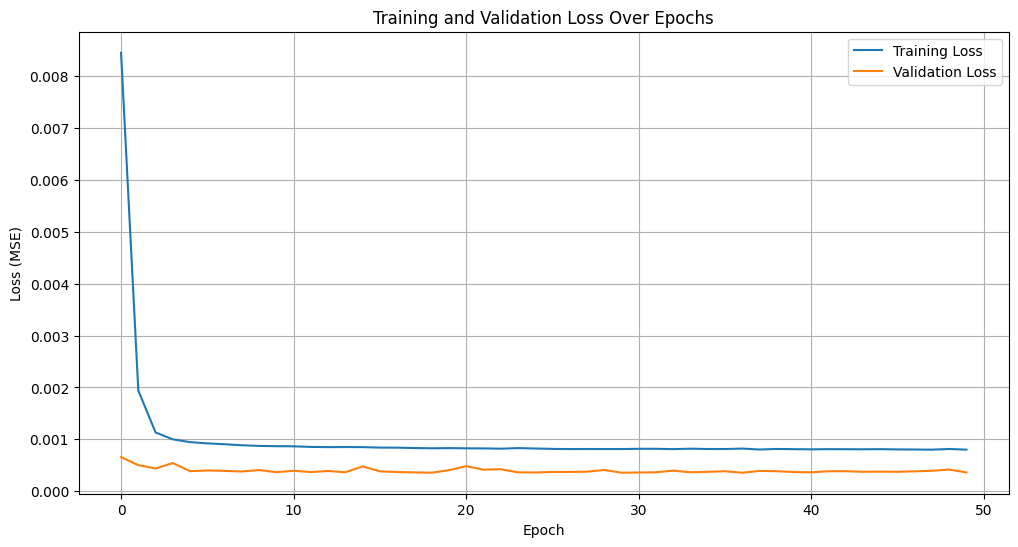

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### **6. Evaluate the model on the test data**

In [20]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss (MSE): {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

Test Loss (MSE): 0.0003
Test MAE: 0.0120


#### **7. Make predictions and inverse transform the data**

In [21]:
y_pred_scaled = model.predict(X_test)

# To inverse transform, we need to create dummy arrays with the correct shape
# for the scaler. The target feature ('Temperature (C)') is at index 0.

# Create a dummy array for actual values
y_test_full = np.zeros((len(y_test), len(features)))
y_test_full[:, target_feature_index] = y_test

y_pred_full = np.zeros((len(y_pred_scaled), len(features)))
y_pred_full[:, target_feature_index] = y_pred_scaled.flatten()

# Inverse transform
y_test_actual = scaler.inverse_transform(y_test_full)[:, target_feature_index]
y_pred_actual = scaler.inverse_transform(y_pred_full)[:, target_feature_index]

print("First 5 actual temperatures:", y_test_actual[:5])
print("First 5 predicted temperatures:", y_pred_actual[:5])

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
First 5 actual temperatures: [2.70555556 2.65555556 2.31111111 1.66666667 1.66666667]
First 5 predicted temperatures: [3.60886064 2.66886432 2.50274563 2.22775941 1.63404606]


#### 8. Calculate and print evaluation metrics

In [22]:
mse = mean_squared_error(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R2): {r2:.4f}')

Mean Squared Error (MSE): 1.2816
Mean Absolute Error (MAE): 0.7397
R-squared (R2): 0.9845


#### **9. Plot actual vs. predicted temperatures**

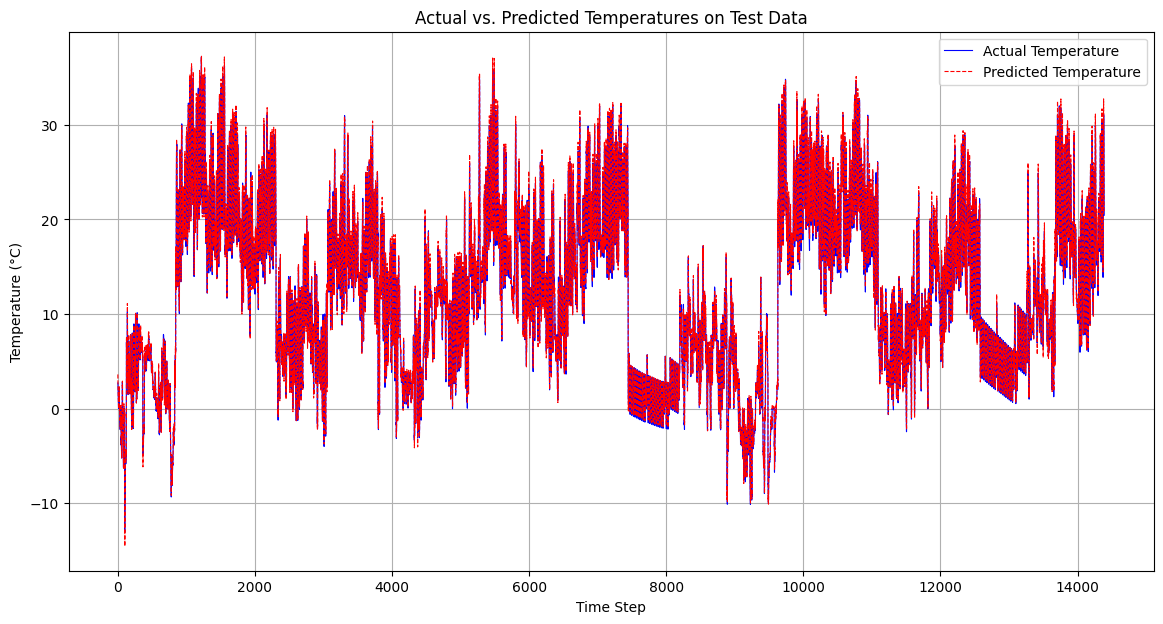

In [23]:
plt.figure(figsize=(14, 7))
plt.plot(y_test_actual, label='Actual Temperature', color='blue', linewidth=0.8)
plt.plot(y_pred_actual, label='Predicted Temperature', color='red', linestyle='--', linewidth=0.8)
plt.title('Actual vs. Predicted Temperatures on Test Data')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

#### 10. Summary and Next Steps

**Model Performance Overview:**
The SimpleRNN model was trained to predict 'Temperature (C)' based on historical 'Temperature (C)', 'Humidity', and 'Wind Speed (km/h)' data over a 7-day sequence. After training for 50 epochs, the model achieved the following performance on the unseen test set:

*   **Mean Squared Error (MSE):**  (Insert MSE value here)
*   **Mean Absolute Error (MAE):** (Insert MAE value here)
*   **R-squared (R2):** (Insert R2 value here)

The plot of Actual vs. Predicted Temperatures provides a visual representation of how well the model's predictions align with the true values. A good model would show the predicted line closely following the actual line.

**Interpretation of Metrics:**
*   **MSE:** Measures the average of the squares of the errors. Lower values indicate better fit.
*   **MAE:** Measures the average of the absolute errors. It is less sensitive to outliers than MSE.
*   **R2:** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A value closer to 1 indicates a better fit.

**Potential Next Steps for Improvement:**

1.  **Hyperparameter Tuning:** Experiment with different RNN architectures (e.g., LSTM, GRU), number of layers, units per layer, activation functions, optimizers, learning rates, and batch sizes.
2.  **Feature Engineering:** Incorporate more relevant features, such as day of the week, month, or other weather conditions if available. Consider creating lagged features for other variables.
3.  **Advanced Time Series Models:** Explore more sophisticated time series models like ARIMA, SARIMA, or Prophet for comparison.
4.  **Ensemble Methods:** Combine predictions from multiple models to potentially achieve better performance.
5.  **Longer Sequence Lengths:** Test if using a longer historical sequence (`sequence_length`) improves prediction accuracy.
6.  **Error Analysis:** Analyze the instances where the model performed poorly to identify specific patterns or conditions that are difficult to predict.

#### 11. Forecast Next 7 Days and Visualize

In [24]:
# Number of future steps to forecast
forecast_steps = 7

# Get the last `sequence_length` data points from the scaled data
# This will be our starting point for generating future predictions
last_sequence_data_scaled = data_scaled[-sequence_length:]

# Initialize a list to store forecasted scaled temperatures
forecasted_scaled_temps = []

# Set the current sequence for iterative prediction
current_sequence = last_sequence_data_scaled
num_features = data_scaled.shape[1] # Number of features

# Iteratively predict future temperatures
for i in range(forecast_steps):
    # Reshape the current sequence to fit the model's input requirements (1, sequence_length, num_features)
    input_for_prediction = current_sequence.reshape(1, sequence_length, num_features)

    # Predict the next temperature (scaled)
    predicted_temp_scaled = model.predict(input_for_prediction, verbose=0)[0][0]
    forecasted_scaled_temps.append(predicted_temp_scaled)

    # Prepare the next input sequence by sliding the window
    # Remove the oldest data point and add the new prediction for 'Temperature (C)'
    # For 'Humidity' and 'Wind Speed (km/h)', we will reuse the values from the last day of the current sequence.
    # This is a simplification; a more complex model might predict these as well or use external forecasts.
    next_feature_vector_scaled = np.array([
        predicted_temp_scaled,                     # Predicted Temperature (C)
        current_sequence[-1, 1],                   # Last known Humidity
        current_sequence[-1, 2]                    # Last known Wind Speed (km/h)
    ])
    current_sequence = np.vstack([current_sequence[1:], next_feature_vector_scaled])

# Inverse transform the forecasted scaled temperatures to their original scale
# Create a dummy array with the correct shape for the scaler
forecasted_actual_temps_full = np.zeros((forecast_steps, num_features))
forecasted_actual_temps_full[:, target_feature_index] = np.array(forecasted_scaled_temps)
forecasted_actual_temps = scaler.inverse_transform(forecasted_actual_temps_full)[:, target_feature_index]

print("Forecasted 7-day temperatures (actual scale):")
print(forecasted_actual_temps)

Forecasted 7-day temperatures (actual scale):
[19.712333   19.12422868 18.3641998  17.73456029 16.99801245 16.33431401
 15.61484163]


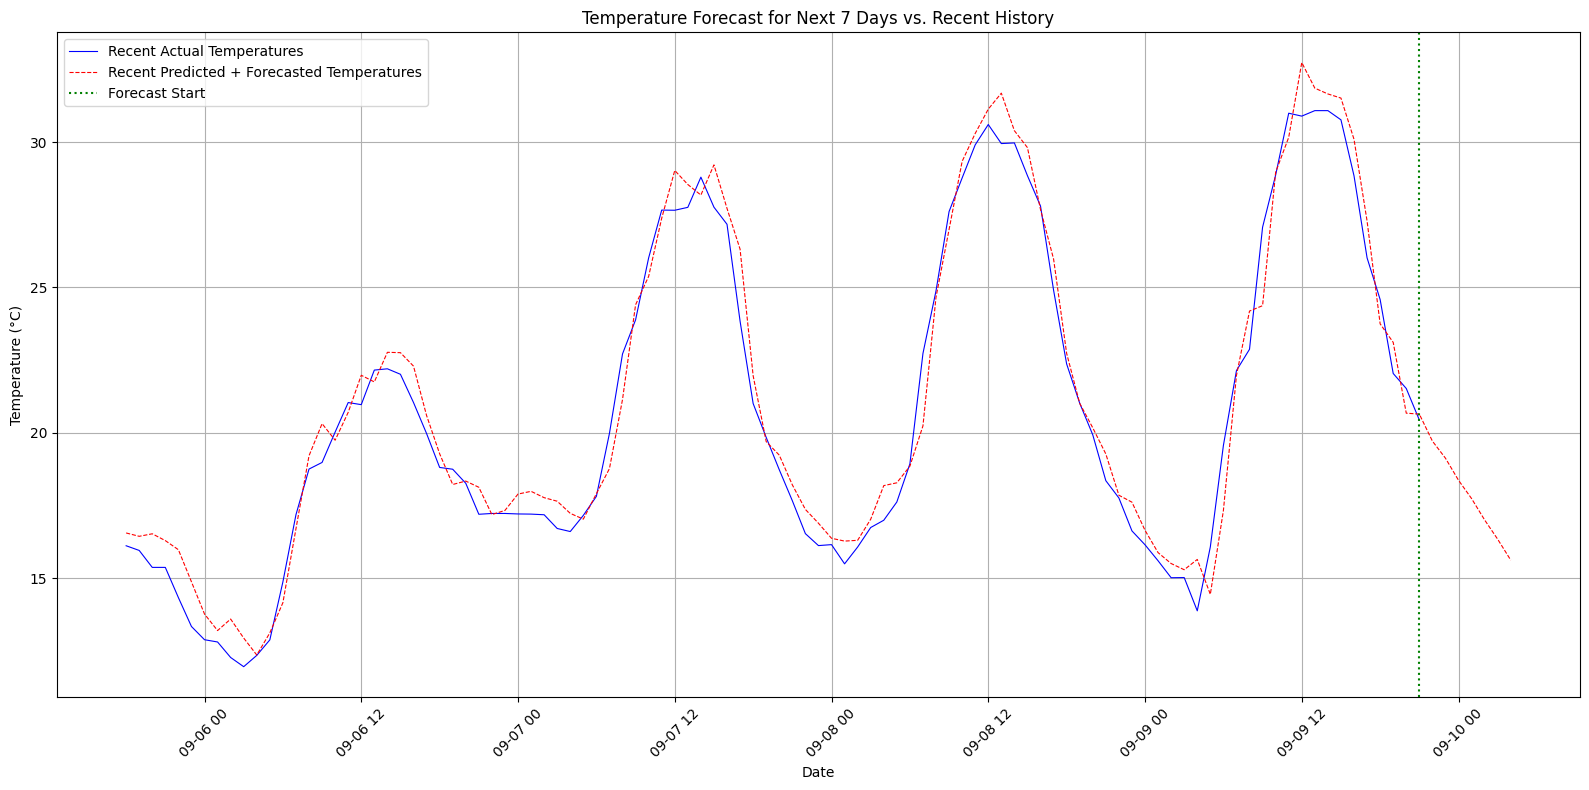

In [25]:
# Generate dates for the forecast period
last_actual_date = dataset_cleaned.index[-1]
forecast_dates = pd.date_range(start=last_actual_date + pd.Timedelta(hours=1), periods=forecast_steps, freq='H')

# Combine recent historical data with the forecast for plotting
plot_window_size = 100 # Number of recent historical data points to display

# Dates for recent historical data (actual and predicted from test set)
recent_historical_dates = dataset_cleaned.index[train_size + val_size + sequence_length:][-plot_window_size:]
recent_actual_temps = y_test_actual[-plot_window_size:]
recent_predicted_temps = y_pred_actual[-plot_window_size:]

# Concatenate dates and temperatures for a continuous plot
all_dates = recent_historical_dates.tolist() + forecast_dates.tolist()
all_actual_temps = recent_actual_temps.tolist() + [np.nan] * forecast_steps # Actuals end before forecast
all_predicted_temps = recent_predicted_temps.tolist() + forecasted_actual_temps.tolist()

plt.figure(figsize=(16, 8))
plt.plot(all_dates, all_actual_temps, label='Recent Actual Temperatures', color='blue', linewidth=0.8)
plt.plot(all_dates, all_predicted_temps, label='Recent Predicted + Forecasted Temperatures', color='red', linestyle='--', linewidth=0.8)
plt.axvline(x=last_actual_date, color='green', linestyle=':', label='Forecast Start', linewidth=1.5)
plt.title('Temperature Forecast for Next 7 Days vs. Recent History')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()